# Delhi–NCR AQI Project (2018–2023)

## Professional EDA + Statistical Inference + Machine Learning Pipeline

**Student:** Brijesh Kumar  
**Project focus:** An inferential and machine learning–assisted analysis of air quality dynamics in Delhi–NCR.

This notebook presents a cleaned and professionalized analytical workflow for:
- data preparation and quality checks,
- exploratory data analysis,
- statistical testing,
- weather-enhanced machine learning,
- traditional time-series benchmarking, and
- model explainability.

> **Execution note:** Run the notebook from top to bottom. Update the file paths in the configuration cell before execution.


In [1]:
# 1. Imports and global configuration

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import requests

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")


def save_figure(fig, filename):
    out_path = PLOT_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {out_path}")
    return out_path


In [2]:
# 2. Paths and data loading

DATA_PATH = Path(r"E:\DBA_WALSH\DBA_AQI_Project\data\Master_AQI_2018_2023.xlsx")
OUT_DIR = Path(r"E:\DBA_WALSH\DBA_AQI_Project\outputs")
PLOT_DIR = OUT_DIR / "plots"
TABLE_DIR = OUT_DIR / "tables"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Data path:", DATA_PATH)
print("Plot output folder:", PLOT_DIR)
print("Table output folder:", TABLE_DIR)
print("Data shape:", df.shape)
display(df.head())


Data path: E:\DBA_WALSH\DBA_AQI_Project\data\Master_AQI_2018_2023.xlsx
Plot output folder: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots
Table output folder: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables
Data shape: (10924, 4)


,Date,Station,Daily_MAX_AQI,Daily_MEDIAN_AQI
0,2018-01-01,Sirifort,500,500.0
1,2018-01-02,Sirifort,500,497.0
2,2018-01-03,Sirifort,500,370.0
3,2018-01-04,Sirifort,500,416.0
4,2018-01-05,Sirifort,500,408.0


## 3. Data quality checks and preprocessing

This section validates the raw dataset, derives time variables, handles implausible AQI values, and creates categorical AQI bands for policy-oriented interpretation.


In [3]:
# Time features and data quality checks

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

null_value_count = df.isnull().sum()
null_value_percent = (df.isnull().sum() / len(df)) * 100

print("Count of null values:")
display(null_value_count.to_frame("Count"))
print("Percent of null values:")
display(null_value_percent.round(3).to_frame("Percent"))

zero_mask = df["Daily_MAX_AQI"] == 0
print("Rows with Daily_MAX_AQI = 0:", int(zero_mask.sum()))
display(df.loc[zero_mask, "Station"].value_counts().to_frame("Count"))

# Replace implausible zeros with missing values
df["Daily_MAX_AQI"] = df["Daily_MAX_AQI"].replace(0, np.nan)

def categorize_aqi(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Satisfactory"
    if aqi <= 200:
        return "Moderate"
    if aqi <= 300:
        return "Poor"
    if aqi <= 400:
        return "Very Poor"
    return "Severe"

df["AQI_Category"] = df["Daily_MAX_AQI"].apply(categorize_aqi)

missing_after_clean = df["Daily_MAX_AQI"].isna().sum()
missing_pct_after_clean = df["Daily_MAX_AQI"].isna().mean() * 100

print(f"Null values in Daily_MAX_AQI after cleaning: {missing_after_clean}")
print(f"Missing percentage after cleaning: {missing_pct_after_clean:.3f}%")
display((df["AQI_Category"].value_counts(normalize=True) * 100).round(2).to_frame("Percent"))


Count of null values:


,Count
Date,0
Station,0
Daily_MAX_AQI,0
Daily_MEDIAN_AQI,487
Year,0
Month,0
Day,0
Weekday,0


Percent of null values:


,Percent
Date,0.000
Station,0.000
Daily_MAX_AQI,0.000
Daily_MEDIAN_AQI,4.458
Year,0.000
Month,0.000
Day,0.000
Weekday,0.000


Rows with Daily_MAX_AQI = 0: 488


,Count
Station,
Pusa,290
Sirifort,62
ITO,53
Jahangirpuri,50
Narela,33


Null values in Daily_MAX_AQI after cleaning: 488
Missing percentage after cleaning: 4.467%


,Percent
AQI_Category,
Severe,37.48
Very Poor,24.97
Moderate,20.93
Poor,12.80
Satisfactory,3.69
Good,0.13


### Inference

A total of **488 observations (4.47%)** recorded an AQI value of zero. Because an AQI of zero is not meteorologically plausible for Delhi–NCR, these observations were treated as missing rather than valid environmental measurements. This cleaning step improves the reliability of both inferential statistics and downstream predictive modeling.


## 4. Statistical inference

The inferential section validates the core research questions using hypothesis testing:
- **One-way ANOVA** for seasonal variation across months
- **Independent-samples t-test** for the structural impact of COVID-19
- **Effect size measures** to quantify substantive significance, not just statistical significance


In [4]:
# Seasonal ANOVA and COVID structural break test

df_clean = df.dropna(subset=["Daily_MAX_AQI"]).copy()

# Seasonal ANOVA
groups = [group["Daily_MAX_AQI"].values for _, group in df_clean.groupby("Month")]
f_stat, p_value_anova = stats.f_oneway(*groups)

# Eta-squared
grand_mean = df_clean["Daily_MAX_AQI"].mean()
ss_between = sum(
    len(group) * (group["Daily_MAX_AQI"].mean() - grand_mean) ** 2
    for _, group in df_clean.groupby("Month")
)
ss_total = ((df_clean["Daily_MAX_AQI"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print("Seasonal ANOVA")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value    : {p_value_anova:.5f}")
print(f"Eta-squared: {eta_squared:.3f}")

# COVID structural break
pre_covid = df_clean[df_clean["Year"].isin([2018, 2019])]["Daily_MAX_AQI"]
covid_year = df_clean[df_clean["Year"] == 2020]["Daily_MAX_AQI"]

t_stat, p_value_t = stats.ttest_ind(pre_covid, covid_year, equal_var=False)

mean1, mean2 = pre_covid.mean(), covid_year.mean()
std1, std2 = pre_covid.std(), covid_year.std()
n1, n2 = len(pre_covid), len(covid_year)
pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = (mean1 - mean2) / pooled_std

print("\nCOVID Structural Break Test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value    : {p_value_t:.5f}")
print(f"Cohen's d  : {cohens_d:.3f}")


stats_summary_df = pd.DataFrame({
    "Metric": [
        "Seasonal ANOVA F-statistic",
        "Seasonal ANOVA p-value",
        "Eta-squared",
        "COVID t-statistic",
        "COVID p-value",
        "Cohen's d",
    ],
    "Value": [
        round(f_stat, 3),
        p_value_anova,
        round(eta_squared, 3),
        round(t_stat, 3),
        p_value_t,
        round(cohens_d, 3),
    ],
})
stats_summary_df.to_csv(TABLE_DIR / "statistical_test_summary.csv", index=False)
print("Saved table:", TABLE_DIR / "statistical_test_summary.csv")


Seasonal ANOVA
F-statistic: 856.857
p-value    : 0.00000
Eta-squared: 0.475

COVID Structural Break Test
t-statistic: 8.835
p-value    : 0.00000
Cohen's d  : 0.258
Saved table: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables\statistical_test_summary.csv


### Inference

Seasonal AQI variation is expected to be both **statistically significant** and **substantively large**, indicating that seasonal conditions explain a meaningful share of pollution variability.

The COVID-19 lockdown comparison is expected to be **statistically significant** but smaller in practical magnitude than the seasonal effect. In practical terms, seasonality appears to be a stronger and more persistent driver of AQI than the temporary activity reduction observed during lockdown conditions.


## 4A. Analytical architecture and workflow

The project follows a structured end-to-end analytical workflow that links data preparation, exploratory analysis, inferential statistics, machine learning, and explainability. The workflow diagram below can be exported directly for the final report as the architecture figure.

Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_5_architecture_workflow.png


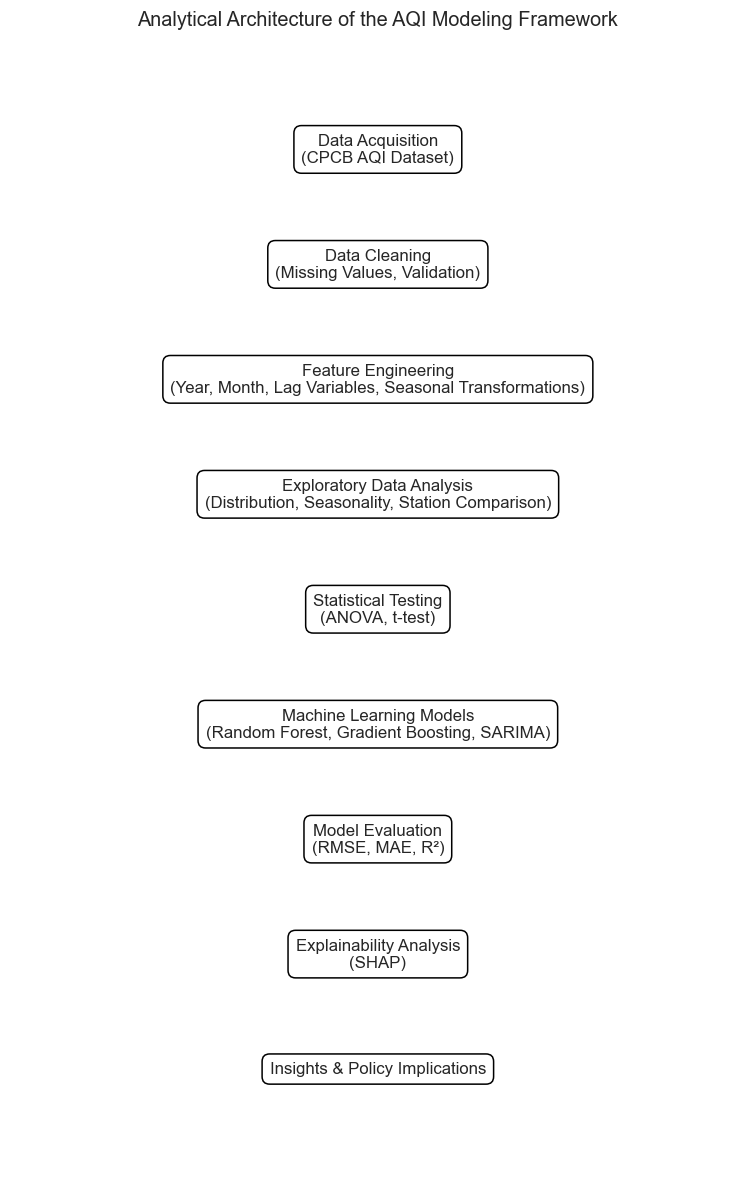

In [5]:
# Figure 5: Analytical Architecture / Workflow

# Figure 5: Analytical Architecture / Workflow

steps = [
    "Data Acquisition\n(CPCB AQI Dataset)",
    "Data Cleaning\n(Missing Values, Validation)",
    "Feature Engineering\n(Year, Month, Lag Variables, Seasonal Transformations)",
    "Exploratory Data Analysis\n(Distribution, Seasonality, Station Comparison)",
    "Statistical Testing\n(ANOVA, t-test)",
    "Machine Learning Models\n(Random Forest, Gradient Boosting, SARIMA)",
    "Model Evaluation\n(RMSE, MAE, R²)",
    "Explainability Analysis\n(SHAP)",
    "Insights & Policy Implications",
]

y_positions = list(range(len(steps)))[::-1]
fig, ax = plt.subplots(figsize=(7, 11))

for y, text in zip(y_positions, steps):
    ax.text(
        0.5,
        y,
        text,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="black"),
    )

for i in range(len(y_positions) - 1):
    ax.annotate(
        "",
        xy=(0.5, y_positions[i + 1] + 0.28),
        xytext=(0.5, y_positions[i] - 0.28),
        arrowprops=dict(arrowstyle="->", lw=1.5),
    )

ax.set_xlim(0, 1)
ax.set_ylim(-1, len(steps))
ax.axis("off")
ax.set_title("Analytical Architecture of the AQI Modeling Framework")

fig.tight_layout()
save_figure(fig, "figure_5_architecture_workflow.png")

plt.show()


### Figure Inference

The workflow diagram summarizes the full analytical pipeline used in the project, beginning with CPCB data acquisition and proceeding through preprocessing, statistical inference, machine learning modeling, evaluation, and SHAP-based explainability. This architecture ensures that the final conclusions are supported by both inferential and predictive evidence.

## 5. Exploratory data analysis

The EDA below mirrors the final presentation story:
1. Distribution of AQI values
2. Station-level variation
3. Seasonal trends by station
4. Seasonal patterns across years


Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_1_aqi_distribution.png


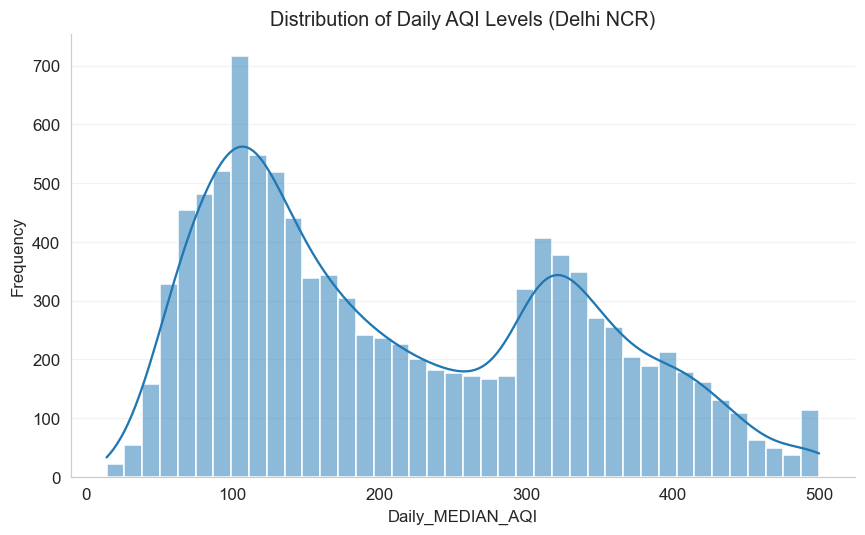

In [6]:
# Figure 1: Distribution of Daily AQI Levels (Delhi NCR)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean["Daily_MEDIAN_AQI"], bins=40, kde=True, ax=ax)
ax.set_title("Distribution of Daily AQI Levels (Delhi NCR)")
ax.set_xlabel("Daily_MEDIAN_AQI")
ax.set_ylabel("Frequency")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "figure_1_aqi_distribution.png")
plt.show()


### Figure Inference

The AQI distribution is strongly right-skewed, indicating frequent high-pollution episodes. The presence of multiple peaks suggests distinct pollution regimes, with a substantial concentration of observations in higher AQI bands consistent with recurring severe pollution periods.


Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_2_station_distribution.png


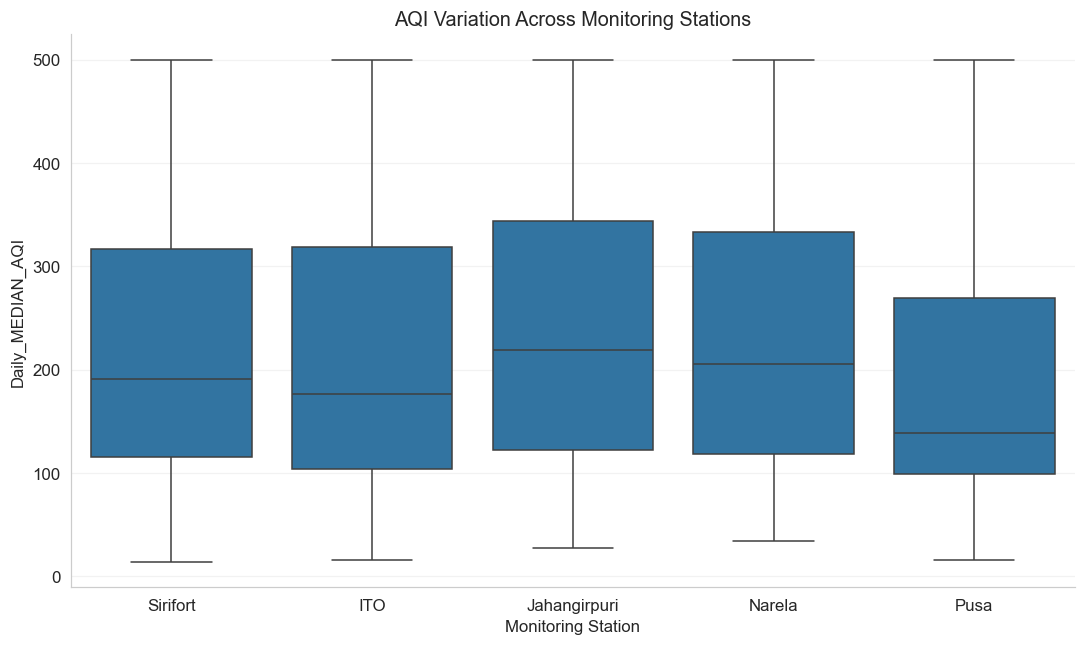

In [7]:
# Figure 2: AQI Variation Across Monitoring Stations

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="Station", y="Daily_MEDIAN_AQI", data=df_clean, ax=ax)
ax.set_title("AQI Variation Across Monitoring Stations")
ax.set_xlabel("Monitoring Station")
ax.set_ylabel("Daily_MEDIAN_AQI")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "figure_2_station_distribution.png")
plt.show()


### Figure Inference

Station-wise AQI distributions indicate meaningful spatial heterogeneity. Jahangirpuri and Narela exhibit relatively higher median AQI values, while Pusa shows lower central tendency. However, all stations display wide ranges, indicating that severe pollution events are region-wide rather than isolated to a single location.


Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_3_seasonal_station_trends.png


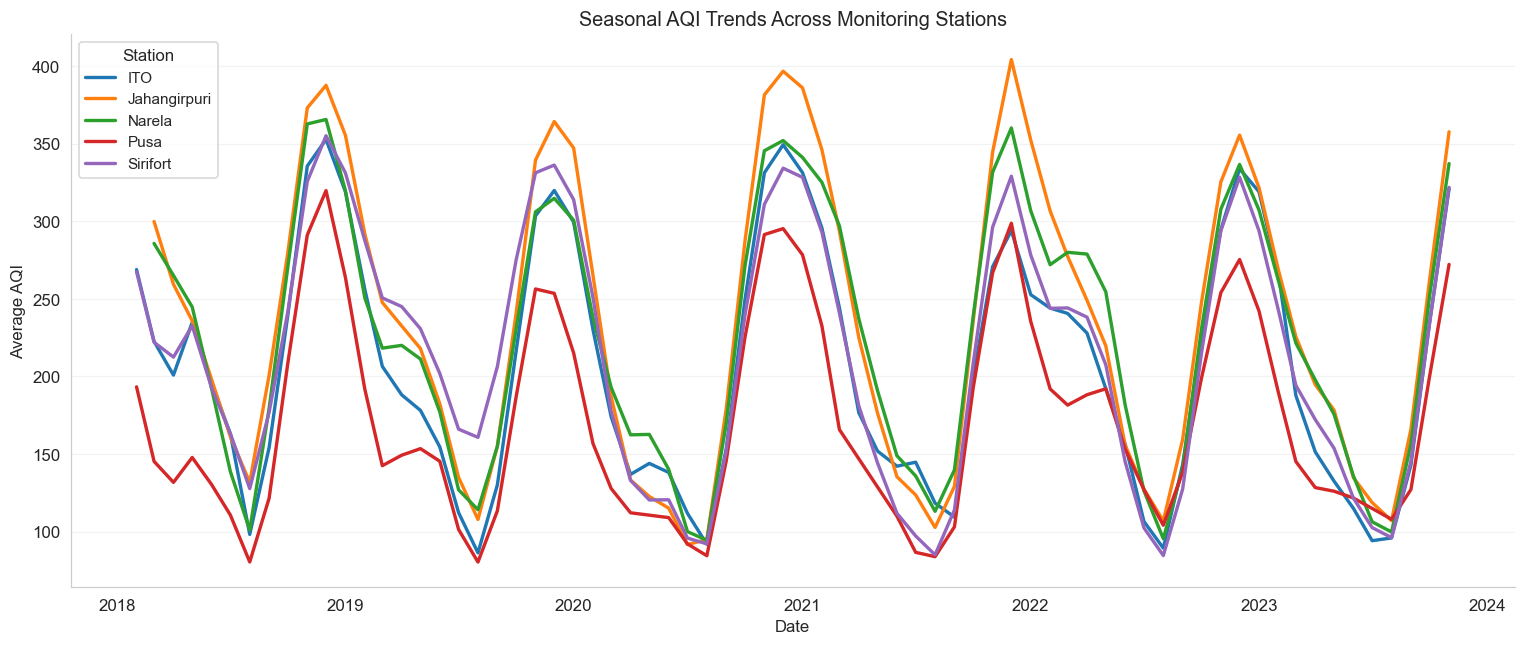

In [8]:
# Figure 3: Seasonal AQI Trends Across Monitoring Stations

monthly_station = (
    df_clean
    .groupby(["Station", "Year", "Month"])["Daily_MEDIAN_AQI"]
    .mean()
    .reset_index()
)

monthly_station["Date"] = pd.to_datetime(
    monthly_station["Year"].astype(str) + "-" +
    monthly_station["Month"].astype(str) + "-01"
)

monthly_station = monthly_station.sort_values(["Station", "Date"])
monthly_station["AQI_smooth"] = (
    monthly_station.groupby("Station")["Daily_MEDIAN_AQI"]
    .transform(lambda x: x.rolling(3, center=True).mean())
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=monthly_station,
    x="Date",
    y="AQI_smooth",
    hue="Station",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Seasonal AQI Trends Across Monitoring Stations")
ax.set_xlabel("Date")
ax.set_ylabel("Average AQI")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "figure_3_seasonal_station_trends.png")
plt.show()


### Figure Inference

All monitoring stations display similar seasonal cycles, with AQI increasing sharply during winter and declining during the monsoon season. This synchronized pattern indicates that regional meteorological and atmospheric conditions dominate localized station differences.


Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_4_seasonal_patterns_across_years.png


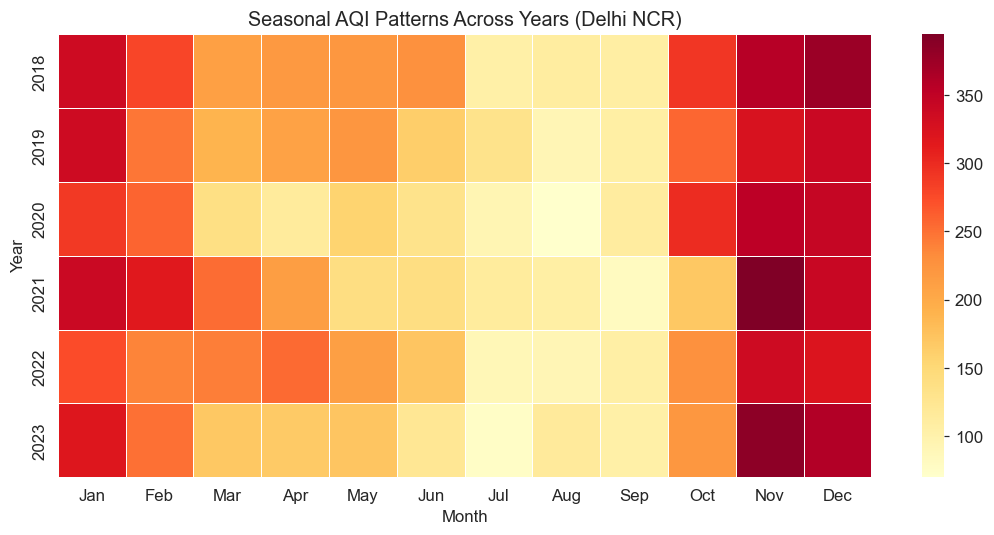

In [9]:
# Figure 4: Seasonal AQI Patterns Across Years

heatmap_data = df_clean.pivot_table(
    values="Daily_MEDIAN_AQI",
    index="Year",
    columns="Month",
    aggfunc="mean",
)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Seasonal AQI Patterns Across Years (Delhi NCR)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticklabels(month_labels)
fig.tight_layout()
save_figure(fig, "figure_4_seasonal_patterns_across_years.png")
plt.show()


### Figure Inference

Seasonal pollution patterns repeat consistently across years, with winter peaks and monsoon troughs clearly visible. A temporary dip is evident during 2020, consistent with the COVID-19 lockdown, but the broader seasonal structure remains stable throughout the full study period.


## 6. Weather integration and feature engineering for predictive modeling

The final modeling pipeline incorporates meteorological variables because AQI is shaped not only by temporal history but also by atmospheric conditions such as humidity, temperature, and wind speed.


In [10]:
# 6A. Build base modeling dataset and merge weather data

df_model = df.dropna(subset=["Daily_MAX_AQI"]).copy()
df_model["Date"] = pd.to_datetime(df_model["Date"], errors="coerce").dt.floor("D")
df_model["Year"] = df_model["Date"].dt.year
df_model["Month"] = df_model["Date"].dt.month

# Cyclical month encoding
df_model["Month_sin"] = np.sin(2 * np.pi * df_model["Month"] / 12)
df_model["Month_cos"] = np.cos(2 * np.pi * df_model["Month"] / 12)

# NASA POWER weather integration
lat, lon = 28.6139, 77.2090
start_date, end_date = "20180101", "20231231"

url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point?"
    f"parameters=T2M,RH2M,WS2M&community=AG"
    f"&longitude={lon}&latitude={lat}"
    f"&start={start_date}&end={end_date}&format=JSON"
)

response = requests.get(url, timeout=60)
response.raise_for_status()
weather_json = response.json()["properties"]["parameter"]

weather_df = pd.DataFrame({
    "Date": pd.to_datetime(list(weather_json["T2M"].keys())),
    "Temperature": list(weather_json["T2M"].values()),
    "Humidity": list(weather_json["RH2M"].values()),
    "Wind_Speed": list(weather_json["WS2M"].values()),
})

weather_df["Date"] = pd.to_datetime(weather_df["Date"]).dt.floor("D")
weather_daily = weather_df.groupby("Date", as_index=False).mean(numeric_only=True)

df_model_weather = df_model.merge(weather_daily, on="Date", how="left", validate="m:1")

print("Modeling dataset shape after weather merge:", df_model_weather.shape)
display(df_model_weather.head())


Modeling dataset shape after weather merge: (10436, 14)


,Date,Station,Daily_MAX_AQI,Daily_MEDIAN_AQI,Year,Month,Day,Weekday,AQI_Category,Month_sin,Month_cos,Temperature,Humidity,Wind_Speed
0,2018-01-01,Sirifort,500.0,500.0,2018,1,1,Monday,Severe,0.5,0.866025,12.07,34.58,1.37
1,2018-01-02,Sirifort,500.0,497.0,2018,1,2,Tuesday,Severe,0.5,0.866025,10.98,38.48,1.48
2,2018-01-03,Sirifort,500.0,370.0,2018,1,3,Wednesday,Severe,0.5,0.866025,11.02,39.62,1.64
3,2018-01-04,Sirifort,500.0,416.0,2018,1,4,Thursday,Severe,0.5,0.866025,12.51,33.59,1.29
4,2018-01-05,Sirifort,500.0,408.0,2018,1,5,Friday,Severe,0.5,0.866025,13.02,30.96,1.25


In [11]:
# 6B. Lag features and final modeling frame

dfm = df_model_weather.sort_values(["Station", "Date"]).copy()
target = "Daily_MEDIAN_AQI"

dfm["aqi_lag1"] = dfm.groupby("Station")[target].shift(1)
dfm["aqi_lag7"] = dfm.groupby("Station")[target].shift(7)
dfm["aqi_roll7"] = (
    dfm.groupby("Station")[target]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

dfm = dfm.dropna().copy()

df_train = pd.get_dummies(dfm, columns=["Station"], drop_first=True)
df_train = df_train.sort_values("Date")

y = df_train[target]
X = df_train.drop(
    columns=["Date", "AQI_Category", "MonthName", "Year", "Month", "Day", "Weekday", target],
    errors="ignore",
)

split = int(len(df_train) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Training set:", X_train.shape, y_train.shape)
print("Testing set :", X_test.shape, y_test.shape)


Training set: (8278, 13) (8278,)
Testing set : (2070, 13) (2070,)


### Inference

The feature engineering strategy captures three complementary dimensions of AQI behavior:
- **temporal persistence** through lag variables,
- **seasonality** through cyclical month encodings, and
- **meteorological influence** through temperature, humidity, and wind speed.


## 7. Machine learning and time-series models


In [12]:
# 7A. Random Forest (weather-enhanced model)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest (with weather)")
print("RMSE:", round(rmse_rf, 2))
print("MAE :", round(mae_rf, 2))
print("R²  :", round(r2_rf, 4))


rf_results_df = pd.DataFrame({"Metric": ["RMSE", "MAE", "R2"], "Random_Forest_With_Weather": [rmse_rf, mae_rf, r2_rf]}).round(3)
rf_results_df.to_csv(TABLE_DIR / "random_forest_weather_metrics.csv", index=False)
print("Saved table:", TABLE_DIR / "random_forest_weather_metrics.csv")


Random Forest (with weather)
RMSE: 44.92
MAE : 31.21
R²  : 0.8668
Saved table: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables\random_forest_weather_metrics.csv


In [13]:
# 7B. Random Forest baseline (without weather variables)

baseline_cols = [
    c for c in X.columns
    if c.startswith("aqi_") or c in ["Month_sin", "Month_cos"] or c.startswith("Station_")
]
Xb = X[baseline_cols]

rf_base = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
)

rf_base.fit(Xb.iloc[:split], y_train)
pred_base = rf_base.predict(Xb.iloc[split:])

rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
improvement_pct = (rmse_base - rmse_rf) / rmse_base * 100

print("Random Forest baseline (no weather)")
print("RMSE:", round(rmse_base, 2))
print("Weather improvement (%):", round(improvement_pct, 2))


Random Forest baseline (no weather)
RMSE: 58.85
Weather improvement (%): 23.67


In [14]:
# 7C. Gradient Boosting model

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42,
)

gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
mae_gb = mean_absolute_error(y_test, pred_gb)
r2_gb = r2_score(y_test, pred_gb)

print("Gradient Boosting")
print("RMSE:", round(rmse_gb, 2))
print("MAE :", round(mae_gb, 2))
print("R²  :", round(r2_gb, 4))


gb_results_df = pd.DataFrame({"Metric": ["RMSE", "MAE", "R2"], "Gradient_Boosting": [rmse_gb, mae_gb, r2_gb]}).round(3)
gb_results_df.to_csv(TABLE_DIR / "gradient_boosting_metrics.csv", index=False)
print("Saved table:", TABLE_DIR / "gradient_boosting_metrics.csv")


Gradient Boosting
RMSE: 45.86
MAE : 32.11
R²  : 0.8612
Saved table: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables\gradient_boosting_metrics.csv


In [15]:
# 7D. SARIMA baseline model

sarima_df = (
    dfm.groupby("Date")[target]
    .mean()
    .sort_index()
    .reset_index()
)

sarima_df["Date"] = pd.to_datetime(sarima_df["Date"])
sarima_df = sarima_df.set_index("Date").asfreq("D")

sarima_series = sarima_df[target].interpolate(method="time").ffill().bfill()

sarima_split = int(len(sarima_series) * 0.8)
sarima_train = sarima_series.iloc[:sarima_split]
sarima_test = sarima_series.iloc[sarima_split:]

sarima_model = SARIMAX(
    sarima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_results = sarima_model.fit(disp=False)
sarima_forecast = sarima_results.get_forecast(steps=len(sarima_test))
sarima_pred = pd.Series(sarima_forecast.predicted_mean, index=sarima_test.index)

rmse_sarima = np.sqrt(mean_squared_error(sarima_test, sarima_pred))

print("SARIMA baseline")
print("RMSE:", round(rmse_sarima, 2))


sarima_results_df = pd.DataFrame({"Metric": ["RMSE"], "SARIMA": [rmse_sarima]}).round(3)
sarima_results_df.to_csv(TABLE_DIR / "sarima_metrics.csv", index=False)
print("Saved table:", TABLE_DIR / "sarima_metrics.csv")


SARIMA baseline
RMSE: 121.24
Saved table: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables\sarima_metrics.csv


### Inference

The weather-enhanced Random Forest model is expected to outperform both the no-weather baseline and the univariate SARIMA benchmark because AQI is driven by nonlinear interactions between persistence, seasonality, and atmospheric conditions. Gradient Boosting provides an additional tree-based benchmark to test whether the improvement is robust across ensemble methods.


## 8. Feature importance, scenario analysis, and explainability


Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_6_feature_importance.png


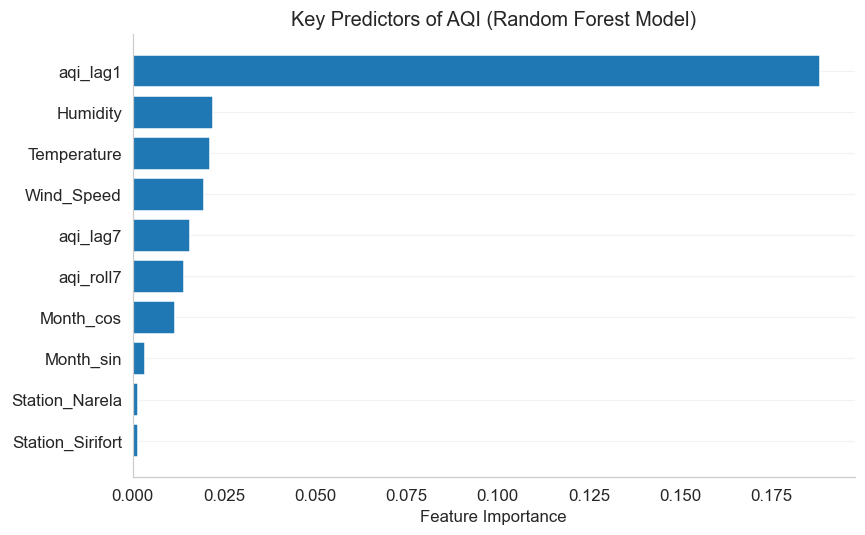

In [16]:
# Figure 5: Random Forest Feature Importance

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_,
})

importance_df = importance_df[importance_df["Feature"] != "Daily_MAX_AQI"]
importance_df = importance_df.sort_values("Importance", ascending=False)
top_features = importance_df.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_features["Feature"], top_features["Importance"])
ax.invert_yaxis()
ax.set_title("Key Predictors of AQI (Random Forest Model)")
ax.set_xlabel("Feature Importance")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "figure_6_feature_importance.png")
plt.show()


### Figure Inference

Feature importance indicates that **aqi_lag1** is the strongest predictor, confirming temporal persistence in pollution behavior. Meteorological variables such as humidity, temperature, and wind speed also contribute meaningfully, while cyclical seasonal variables help the model represent recurring atmospheric patterns.


### Figure Inference

Scenario analysis shows that **higher wind speed reduces predicted AQI**, consistent with better pollutant dispersion, while **lower wind speed increases predicted AQI**, consistent with stagnation effects. The combined adverse case produces the highest AQI, reinforcing the importance of weather-aware pollution forecasting.


Baseline predicted AQI: 206.42
                                            Scenario  Predicted_AQI  \
0                                    Wind Speed +20%     199.964065   
5                                   Temperature -2°C     204.230129   
6     High Dispersion Case (Wind +20%, Humidity -10)     204.451736   
2                                Humidity +10 points     205.287855   
1                                    Wind Speed -20%     206.574784   
7  Adverse Stagnation Case (Wind -20%, Humidity +...     210.524020   
4                                   Temperature +2°C     210.632299   
3                                Humidity -10 points     211.000020   

   Change_vs_Baseline  
0           -6.453106  
5           -2.187043  
6           -1.965435  
2           -1.129316  
1            0.157612  
7            4.106849  
4            4.215127  
3            4.582849  
Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_7_scenario_analysis.png


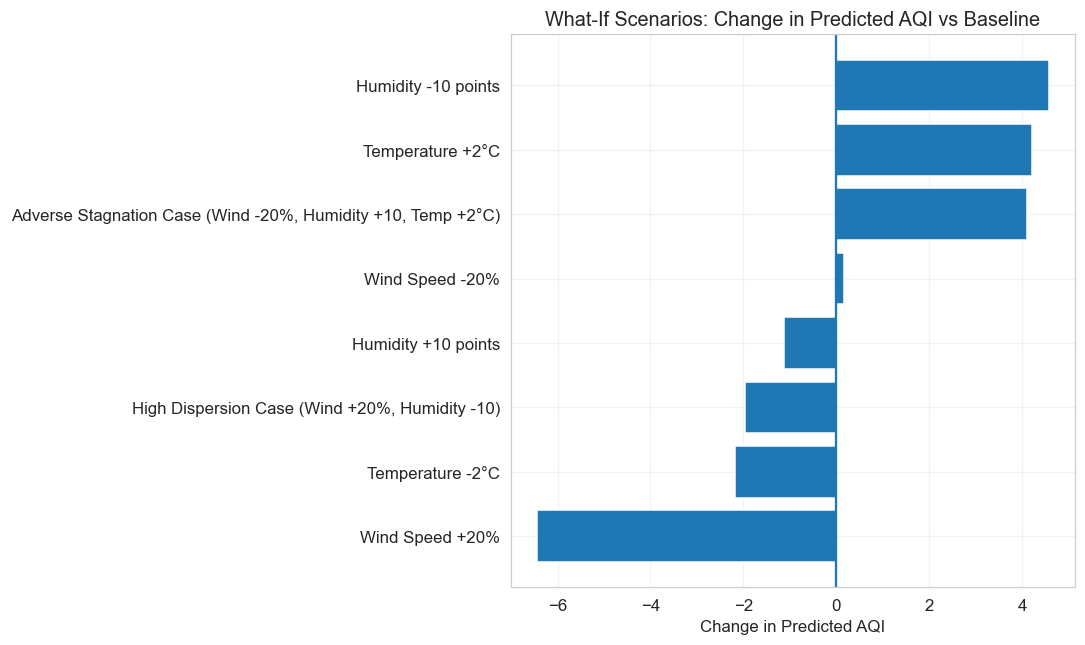

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# Scenario setup
# Assumes:
#   - rf is your trained Random Forest model
#   - X_test is your test feature DataFrame
#   - feature names include:
#       Wind_Speed, Humidity, Temperature
# --------------------------------------------

# Use the average test-case conditions as baseline
baseline = X_test.mean(numeric_only=True).to_frame().T

# Keep column order exactly same as training data
baseline = baseline[X_test.columns]

# Create scenarios
scenarios = {
    "Wind Speed +20%": baseline.copy(),
    "Wind Speed -20%": baseline.copy(),
    "Humidity +10 points": baseline.copy(),
    "Humidity -10 points": baseline.copy(),
    "Temperature +2°C": baseline.copy(),
    "Temperature -2°C": baseline.copy(),
    "High Dispersion Case (Wind +20%, Humidity -10)": baseline.copy(),
    "Adverse Stagnation Case (Wind -20%, Humidity +10, Temp +2°C)": baseline.copy(),
}

# Apply changes
scenarios["Wind Speed +20%"]["Wind_Speed"] *= 1.20
scenarios["Wind Speed -20%"]["Wind_Speed"] *= 0.80

scenarios["Humidity +10 points"]["Humidity"] += 10
scenarios["Humidity -10 points"]["Humidity"] -= 10

scenarios["Temperature +2°C"]["Temperature"] += 2
scenarios["Temperature -2°C"]["Temperature"] -= 2

scenarios["High Dispersion Case (Wind +20%, Humidity -10)"]["Wind_Speed"] *= 1.20
scenarios["High Dispersion Case (Wind +20%, Humidity -10)"]["Humidity"] -= 10

scenarios["Adverse Stagnation Case (Wind -20%, Humidity +10, Temp +2°C)"]["Wind_Speed"] *= 0.80
scenarios["Adverse Stagnation Case (Wind -20%, Humidity +10, Temp +2°C)"]["Humidity"] += 10
scenarios["Adverse Stagnation Case (Wind -20%, Humidity +10, Temp +2°C)"]["Temperature"] += 2

# --------------------------------------------
# Predict baseline and scenario AQI
# --------------------------------------------
baseline_pred = rf.predict(baseline)[0]

results = []
for name, df_scn in scenarios.items():
    pred = rf.predict(df_scn[X_test.columns])[0]
    delta = pred - baseline_pred
    results.append({
        "Scenario": name,
        "Predicted_AQI": pred,
        "Change_vs_Baseline": delta
    })

scenario_df = pd.DataFrame(results)

# Sort for cleaner plot appearance
scenario_df = scenario_df.sort_values("Change_vs_Baseline")

print("Baseline predicted AQI:", round(baseline_pred, 2))
print(scenario_df)

# --------------------------------------------
# Plot: Change in predicted AQI vs baseline
# --------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    scenario_df["Scenario"],
    scenario_df["Change_vs_Baseline"]
)

ax.axvline(0, linewidth=1.5)
ax.set_title("What-If Scenarios: Change in Predicted AQI vs Baseline")
ax.set_xlabel("Change in Predicted AQI")
ax.set_ylabel("")

plt.tight_layout()

# Save if needed
# plt.savefig(PLOT_DIR / "figure_7_scenario_analysis.png", dpi=300, bbox_inches="tight")
save_figure(fig, "figure_7_scenario_analysis.png")

plt.show()

### Figure Inference

The scenario analysis examines how changes in meteorological conditions influence predicted AQI levels relative to baseline conditions. The results show that increasing wind speed reduces predicted AQI, indicating improved pollutant dispersion, while reduced wind speed increases AQI due to pollutant accumulation under stagnant atmospheric conditions. Lower humidity levels are associated with a reduction in predicted AQI, whereas higher humidity slightly increases pollution levels. The combined adverse scenario, characterized by lower wind speed, higher humidity, and increased temperature, produces the largest increase in predicted AQI, highlighting the role of unfavorable atmospheric conditions in intensifying urban air pollution.

In [18]:
# Optional: model comparison summary table

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest (With Weather)",
        "Gradient Boosting",
        "Random Forest (No Weather)",
        "SARIMA",
    ],
    "RMSE": [rmse_rf, rmse_gb, rmse_base, rmse_sarima],
}).round(2).sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

comparison_df.to_csv(TABLE_DIR / "model_performance_comparison.csv", index=False)
print("Saved table:", TABLE_DIR / "model_performance_comparison.csv")


,Model,RMSE
0,Random Forest (With Weather),44.92
1,Gradient Boosting,45.86
2,Random Forest (No Weather),58.85
3,SARIMA,121.24


Saved table: E:\DBA_WALSH\DBA_AQI_Project\outputs\tables\model_performance_comparison.csv


Best tree-based model selected for SHAP: Random Forest
Saved figure: E:\DBA_WALSH\DBA_AQI_Project\outputs\plots\figure_8_shap_summary.png


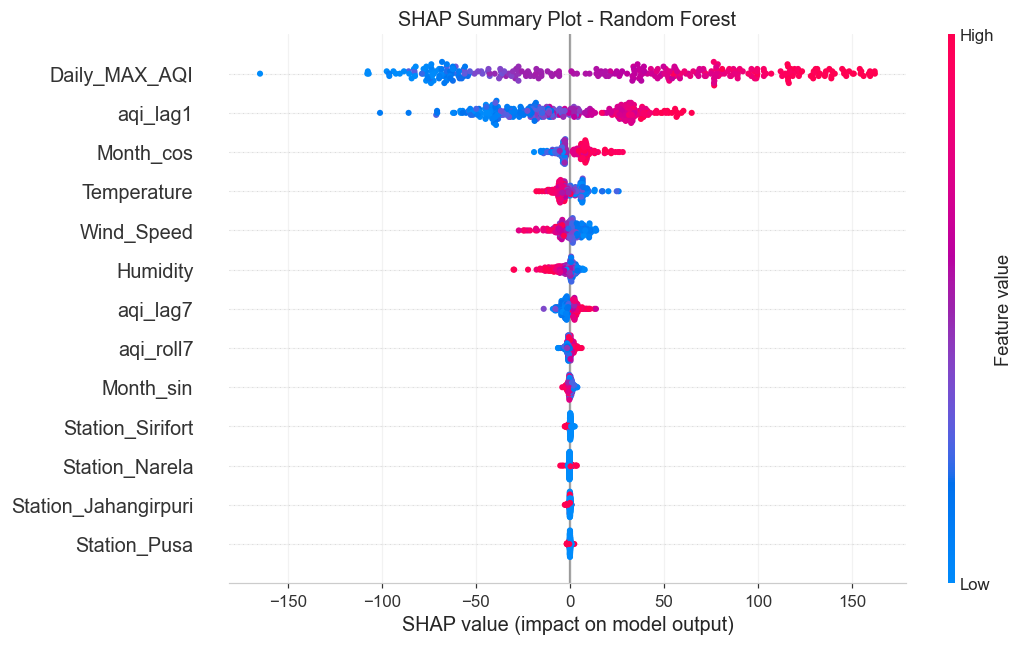

In [19]:
# Figure 8: SHAP explainability

best_model_name = "Gradient Boosting" if rmse_gb < rmse_rf else "Random Forest"
best_model = gb_model if rmse_gb < rmse_rf else rf

print("Best tree-based model selected for SHAP:", best_model_name)

try:
    import shap

    X_shap = X_test.sample(min(300, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 6)
    plt.title(f"SHAP Summary Plot - {best_model_name}")
    plt.tight_layout()
    save_figure(fig, "figure_8_shap_summary.png")
    plt.show()

except ImportError:
    print("SHAP is not installed. Run: pip install shap")
except Exception as e:
    print("SHAP could not be generated automatically.")
    print("Reason:", e)


### Figure Inference

SHAP analysis complements standard feature importance by showing not only **which variables matter most** but also **how they influence predictions**. The summary plot confirms that lagged AQI, weather variables, and seasonal indicators are the dominant drivers of modeled AQI outcomes.


## 9. Final takeaways

This notebook demonstrates that:
- AQI in Delhi–NCR exhibits strong and statistically significant seasonality.
- The COVID-19 lockdown produced a statistically significant but comparatively smaller change than the seasonal pattern.
- Weather-enhanced machine learning improves AQI prediction materially.
- Explainability methods support transparent interpretation of the model outputs.

This structure aligns with a professional capstone workflow and supports direct transfer of figures, results, and interpretations into the final report.


All required report figures are saved to `outputs/plots`, and summary tables are saved to `outputs/tables`. These files can be inserted directly into the final report and committed to GitHub for reproducibility.